# Лабораторная работа: Рекомендательные системы

## Импорт библиотек и инициализация

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Настройки для визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('Библиотеки загружены ')

Библиотеки загружены 


# 1. ЗАГРУЗКА И СУБДИСКРЕТИЗАЦИЯ ДАННЫХ

In [82]:
print("Загрузка данных")
interactions = pd.read_csv('interactions.csv')
items = pd.read_csv('items.csv')
users = pd.read_csv('users.csv')

print(f"Исходные размеры:")
print(f"  interactions: {interactions.shape[0]:,} строк ({interactions.memory_usage(deep=True).sum()/1024/1024:.1f} MB)")
print(f"  items: {items.shape[0]:,} строк ({items.memory_usage(deep=True).sum()/1024/1024:.1f} MB)")
print(f"  users: {users.shape[0]:,} строк ({users.memory_usage(deep=True).sum()/1024/1024:.1f} MB)")
print(f"Общий размер датасета: {(interactions.memory_usage(deep=True).sum() + items.memory_usage(deep=True).sum() + users.memory_usage(deep=True).sum())/1024/1024:.1f} MB")

Загрузка данных
Исходные размеры:
  interactions: 1,533,078 строк (133.0 MB)
  items: 59,599 строк (23.9 MB)
  users: 142,888 строк (9.5 MB)
Общий размер датасета: 166.5 MB


In [83]:
# Субдискретизация для управляемости
np.random.seed(42)
n_users_sample = 5000
n_items_sample = 3000

sampled_users = np.random.choice(interactions['user_id'].unique(), n_users_sample, replace=False)
sampled_items = np.random.choice(interactions['item_id'].unique(), n_items_sample, replace=False)

interactions = interactions[
    (interactions['user_id'].isin(sampled_users)) &
    (interactions['item_id'].isin(sampled_items))
].copy()

items = items[items['id'].isin(sampled_items)].copy()
users = users[users['user_id'].isin(sampled_users)].copy()

# Переименование колонки
items = items.rename(columns={'id': 'item_id'})
interactions['rating'] = pd.to_numeric(interactions['rating'], errors='coerce')

print(f"После субдискретизации:")
print(f"  interactions: {interactions.shape[0]:,} строк")
print(f"  items: {items.shape[0]:,} строк")
print(f"  users: {users.shape[0]:,} строк")
print(f"Уникальные значения:")
print(f"  Пользователей: {interactions['user_id'].nunique():,}")
print(f"  Книг: {interactions['item_id'].nunique():,}")

После субдискретизации:
  interactions: 2,502 строк
  items: 3,000 строк
  users: 4,483 строк
Уникальные значения:
  Пользователей: 1,668
  Книг: 1,406


## 2. Анализ и статистика данных

In [84]:
# Анализ рейтингов
ratings_data = interactions['rating'].dropna()

print("РАСПРЕДЕЛЕНИЕ РЕЙТИНГОВ")
print(f"Всего взаимодействий: {len(interactions):,}")
print(f"Взаимодействий с рейтингом: {len(ratings_data):,} ({len(ratings_data)/len(interactions)*100:.1f}%)")
print(f"Взаимодействий БЕЗ рейтинга: {len(interactions) - len(ratings_data):,} ({(len(interactions)-len(ratings_data))/len(interactions)*100:.1f}%)")

print(f"Статистика рейтингов:")
print(f"  Mean:   {ratings_data.mean():.2f}")
print(f"  Median: {ratings_data.median():.2f}")
print(f"  Std:    {ratings_data.std():.2f}")
print(f"  Min:    {ratings_data.min():.2f}")
print(f"  Max:    {ratings_data.max():.2f}")

print(f"Распределение оценок:")
print(ratings_data.value_counts().sort_index())

РАСПРЕДЕЛЕНИЕ РЕЙТИНГОВ
Всего взаимодействий: 2,502
Взаимодействий с рейтингом: 483 (19.3%)
Взаимодействий БЕЗ рейтинга: 2,019 (80.7%)
Статистика рейтингов:
  Mean:   4.63
  Median: 5.00
  Std:    0.86
  Min:    1.00
  Max:    5.00
Распределение оценок:
rating
1.0     13
2.0      5
3.0     28
4.0     55
5.0    382
Name: count, dtype: int64


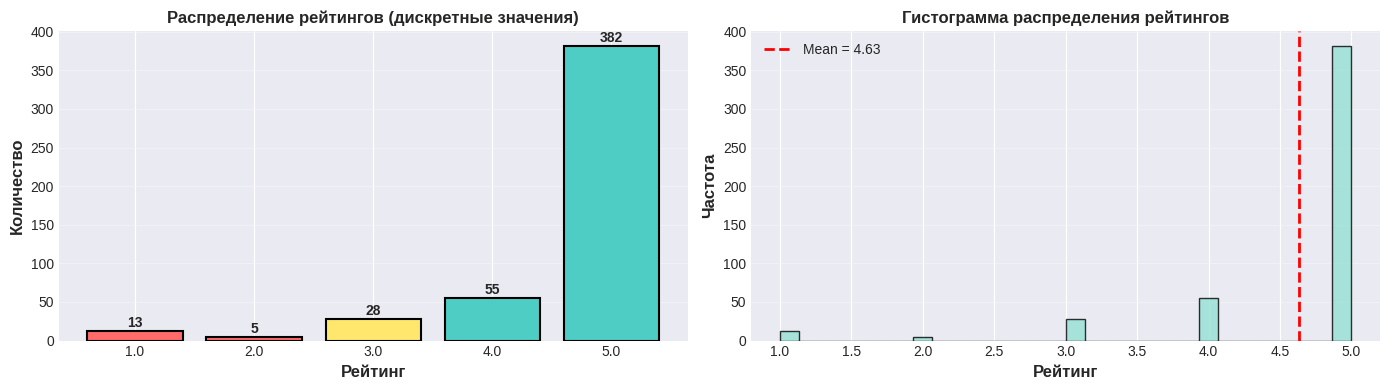

График сохранён


In [85]:
# Визуализация распределения рейтингов
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# График 1: По дискретным значениям
ax1 = axes[0]
rating_counts = ratings_data.value_counts().sort_index()
colors = ['#FF6B6B' if v < 3 else '#FFE66D' if v < 4 else '#4ECDC4' for v in rating_counts.index]
ax1.bar(rating_counts.index.astype(str), rating_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Рейтинг', fontsize=12, fontweight='bold')
ax1.set_ylabel('Количество', fontsize=12, fontweight='bold')
ax1.set_title('Распределение рейтингов (дискретные значения)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Добавить значения
for i, v in enumerate(rating_counts.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# График 2: Гистограмма
ax2 = axes[1]
ax2.hist(ratings_data, bins=30, color='#95E1D3', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Рейтинг', fontsize=12, fontweight='bold')
ax2.set_ylabel('Частота', fontsize=12, fontweight='bold')
ax2.set_title('Гистограмма распределения рейтингов', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axvline(ratings_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {ratings_data.mean():.2f}')
ax2.legend()

plt.tight_layout()
plt.show()

print("График сохранён")

In [86]:
# Коэффициент разреженности (Sparsity Ratio)
print("Коэффициент разреженности (Sparcity ratio)")

max_possible_interactions = interactions['user_id'].nunique() * interactions['item_id'].nunique()
actual_interactions = len(interactions)
sparsity_ratio = 1 - (actual_interactions / max_possible_interactions)

print(f"Формула: Sparsity = 1 - (Фактические взаимодействия / Макс. возможные)")
print(f"Максимально возможных взаимодействий: {max_possible_interactions:,}")
print(f"Фактических взаимодействий: {actual_interactions:,}")
print(f" Sparsity Ratio: {sparsity_ratio:.4f} ({sparsity_ratio*100:.2f}%)")


Коэффициент разреженности (Sparcity ratio)
Формула: Sparsity = 1 - (Фактические взаимодействия / Макс. возможные)
Максимально возможных взаимодействий: 2,345,208
Фактических взаимодействий: 2,502
 Sparsity Ratio: 0.9989 (99.89%)


Вывод: Матрица ЭКСТРЕМАЛЬНО разреженная, Item-based CF лучше справляется с такими данными"

In [87]:

print("Проблема холодеого старта (Cold start)")

min_interactions_threshold = 5

user_interaction_counts = interactions['user_id'].value_counts()
cold_start_users = (user_interaction_counts < min_interactions_threshold).sum()
cold_start_users_pct = cold_start_users / interactions['user_id'].nunique() * 100

item_interaction_counts = interactions['item_id'].value_counts()
cold_start_items = (item_interaction_counts < min_interactions_threshold).sum()
cold_start_items_pct = cold_start_items / interactions['item_id'].nunique() * 100

print(f"Пороговое значение: < {min_interactions_threshold} взаимодействий")
print(f"ПОЛЬЗОВАТЕЛИ:")
print(f"   Холодный старт: {cold_start_users:,} ({cold_start_users_pct:.1f}%)")
print(f"   Нормальные: {interactions['user_id'].nunique() - cold_start_users:,} ({100-cold_start_users_pct:.1f}%)")

print(f"КНИГИ:")
print(f"   Холодный старт: {cold_start_items:,} ({cold_start_items_pct:.1f}%)")
print(f"   Нормальные: {interactions['item_id'].nunique() - cold_start_items:,} ({100-cold_start_items_pct:.1f}%)")

print(f"Вывод: Значительная доля пользователей и книг имеют мало взаимодействий")
print(f"   Требуется гибридный подход (контентная + коллаборативная)")

Проблема холодеого старта (Cold start)
Пороговое значение: < 5 взаимодействий
ПОЛЬЗОВАТЕЛИ:
   Холодный старт: 1,623 (97.3%)
   Нормальные: 45 (2.7%)
КНИГИ:
   Холодный старт: 1,347 (95.8%)
   Нормальные: 59 (4.2%)
Вывод: Значительная доля пользователей и книг имеют мало взаимодействий
   Требуется гибридный подход (контентная + коллаборативная)


## 3. Подготовка данных и разделение train/test

In [88]:
print("Подготовка данных")
# Используем только взаимодействия с рейтингами
interactions_with_ratings = interactions[interactions['rating'].notna()].copy()
print(f"Взаимодействия с рейтингами: {len(interactions_with_ratings)}")

# Случайное перемешивание и разделение 80/20
interactions_with_ratings = interactions_with_ratings.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(0.8 * len(interactions_with_ratings))

train_data = interactions_with_ratings[:split_idx].copy()
test_data = interactions_with_ratings[split_idx:].copy()

print(f"Разделение Train/Test (80/20):")
print(f"   Train: {len(train_data)} взаимодействий ({len(train_data)/len(interactions_with_ratings)*100:.1f}%)")
print(f"     Пользователей: {train_data['user_id'].nunique()}")
print(f"     Товаров: {train_data['item_id'].nunique()}")

print(f"   Test: {len(test_data)} взаимодействий ({len(test_data)/len(interactions_with_ratings)*100:.1f}%)")
print(f"     Пользователей: {test_data['user_id'].nunique()}")
print(f"     Товаров: {test_data['item_id'].nunique()}")

Подготовка данных
Взаимодействия с рейтингами: 483
Разделение Train/Test (80/20):
   Train: 386 взаимодействий (79.9%)
     Пользователей: 280
     Товаров: 326
   Test: 97 взаимодействий (20.1%)
     Пользователей: 90
     Товаров: 96


# 4. Контентная фильтрация (Content-based filter)

In [89]:
# Попытка найти целевую книгу
target_book = items[items['authors'].str.contains('Айн Рэнд', case=False, na=False)]

if len(target_book) == 0:
    # Если не найдена, используем первую популярную книгу
    top_items = train_data['item_id'].value_counts().head(1).index
    target_book = items[items['item_id'].isin(top_items)]
    print(f" Книга 'Атлант расправил плечи' не найдена.")
    print(f"    Используем вместо неё популярную книгу из датасета.")
else:
    print(f" Найдена книга: '{target_book['title'].values[0]}'")

target_item_id = target_book['item_id'].values[0]
target_book_title = target_book['title'].values[0]

print(f"Целевая книга для анализа: {target_book_title}")
print(f"   ID: {target_item_id}")

 Книга 'Атлант расправил плечи' не найдена.
    Используем вместо неё популярную книгу из датасета.
Целевая книга для анализа: Пять языков любви
   ID: 292629


In [90]:
# Подготовка данных для контентной фильтрации
items_with_data = items.dropna(subset=['title', 'genres']).copy()
items_with_data = items_with_data.reset_index(drop=True)

# Комбинируем признаки
items_with_data['content'] = (
    items_with_data['title'].fillna('') + ' ' +
    items_with_data['genres'].fillna('')
)

print(f"Подготовка данных для контентной фильтрации:")
print(f"  Книг с описаниями: {len(items_with_data)}")
print(f"  Признаки: заголовок + жанры")
print(f"Пример контента книги '{target_book_title}':")
target_content = items_with_data[items_with_data['item_id'] == target_item_id]
if len(target_content) > 0:
    print(f"  {target_content['content'].values[0][:100]}...")

Подготовка данных для контентной фильтрации:
  Книг с описаниями: 2998
  Признаки: заголовок + жанры
Пример контента книги 'Пять языков любви':
  Пять языков любви Семейная психология,Практическая психология...


Метод 1: CountVectorizer + Cosine Similarity

In [91]:

cv = CountVectorizer(max_features=100, stop_words='english')
cv_matrix = cv.fit_transform(items_with_data['content'].values)

# Находим целевую книгу
target_matches = items_with_data[items_with_data['item_id'] == target_item_id]
if len(target_matches) > 0:
    target_idx = target_matches.index[0]
else:
    target_idx = 0

target_vector = cv_matrix[target_idx]

# Вычисляем косинусное сходство
cos_sim = cosine_similarity(target_vector, cv_matrix)[0]
top_indices_cos = np.argsort(cos_sim)[-6:-1][::-1]  # Top 5 (исключая саму себя)

print(f"\nTop-5 похожих книг:")
cv_recommendations = []
for rank, idx in enumerate(top_indices_cos, 1):
    sim = cos_sim[idx]
    item_data = items_with_data.iloc[idx]
    item_id = item_data['item_id']
    title = item_data['title']
    print(f"  {rank}. {title[:50]:<50} (сходство: {sim:.4f})")
    cv_recommendations.append((item_id, title, sim))


Top-5 похожих книг:
  1. Мечты сбываются!                                   (сходство: 0.9487)
  2. Психология кризисных и экстремальных ситуаций. Инд (сходство: 0.9439)
  3. Ревность. Как с ней жить и сохранить отношения     (сходство: 0.9037)
  4. Психология искусства                               (сходство: 0.8944)
  5. Рожденная женщиной. Твой путь к женской силе       (сходство: 0.8944)


Метод 2: TfidfVectorizer + Cosine Similarity

In [92]:
tv = TfidfVectorizer(max_features=100, stop_words='english')
tv_matrix = tv.fit_transform(items_with_data['content'].values)
target_vector_tv = tv_matrix[target_idx]

cos_sim_tfidf = cosine_similarity(target_vector_tv, tv_matrix)[0]
top_indices_tfidf = np.argsort(cos_sim_tfidf)[-6:-1][::-1]

print(f"\nTop-5 похожих книг:")
tv_recommendations = []
for rank, idx in enumerate(top_indices_tfidf, 1):
    sim = cos_sim_tfidf[idx]
    item_data = items_with_data.iloc[idx]
    item_id = item_data['item_id']
    title = item_data['title']
    print(f"  {rank}. {title[:50]:<50} (сходство: {sim:.4f})")
    tv_recommendations.append((item_id, title, sim))


Top-5 похожих книг:
  1. Мечты сбываются!                                   (сходство: 0.9431)
  2. Психология кризисных и экстремальных ситуаций. Инд (сходство: 0.9277)
  3. Ревность. Как с ней жить и сохранить отношения     (сходство: 0.9027)
  4. Еще кусочек! Как взять под контроль зверский аппет (сходство: 0.8573)
  5. Движение любви. Мужчина и Женщина                  (сходство: 0.8349)


Метод 3: CountVectorizer + Euclidean Distance

In [93]:
eucl_dist = euclidean_distances(target_vector, cv_matrix)[0]
top_indices_eucl = np.argsort(eucl_dist)[:5]

print(f"\nTop-5 похожих книг (меньше расстояние = лучше):")
eucl_recommendations = []
for rank, idx in enumerate(top_indices_eucl, 1):
    dist = eucl_dist[idx]
    item_data = items_with_data.iloc[idx]
    item_id = item_data['item_id']
    title = item_data['title']
    print(f"  {rank}. {title[:50]:<50} (расстояние: {dist:.4f})")
    eucl_recommendations.append((item_id, title, dist))


Top-5 похожих книг (меньше расстояние = лучше):
  1. Пять языков любви                                  (расстояние: 0.0000)
  2. Мечты сбываются!                                   (расстояние: 1.0000)
  3. Рожденная женщиной. Твой путь к женской силе       (расстояние: 1.4142)
  4. Энциклопедия начинающего семейного психолога       (расстояние: 1.4142)
  5. Краткое содержание «Я слышу вас насквозь. Эффектив (расстояние: 1.4142)


Метод 4 TfidfVectorizer + Manhattan Distance

In [94]:
manh_dist = manhattan_distances(target_vector_tv, tv_matrix)[0]
top_indices_manh = np.argsort(manh_dist)[:5]

print(f"Top-5 похожих книг (меньше расстояние = лучше):")
manh_recommendations = []
for rank, idx in enumerate(top_indices_manh, 1):
    dist = manh_dist[idx]
    item_data = items_with_data.iloc[idx]
    item_id = item_data['item_id']
    title = item_data['title']
    print(f"  {rank}. {title[:50]:<50} (расстояние: {dist:.4f})")
    manh_recommendations.append((item_id, title, dist))

Top-5 похожих книг (меньше расстояние = лучше):
  1. Пять языков любви                                  (расстояние: 0.0000)
  2. Мечты сбываются!                                   (расстояние: 0.4770)
  3. Психология кризисных и экстремальных ситуаций. Инд (расстояние: 0.5365)
  4. Рожденная женщиной. Твой путь к женской силе       (расстояние: 0.7155)
  5. Движение любви. Мужчина и Женщина                  (расстояние: 0.7155)


Анализ консистентности рекомендаций

In [95]:
# Собираем все рекомендации
all_recommendations = []
all_recommendations.extend([(item_id, title) for item_id, title, _ in cv_recommendations])
all_recommendations.extend([(item_id, title) for item_id, title, _ in tv_recommendations])
all_recommendations.extend([(item_id, title) for item_id, title, _ in eucl_recommendations])
all_recommendations.extend([(item_id, title) for item_id, title, _ in manh_recommendations])

# Подсчитываем повторения
rec_counts = {}
for item_id, title in all_recommendations:
    if item_id not in rec_counts:
        rec_counts[item_id] = {'count': 0, 'title': title}
    rec_counts[item_id]['count'] += 1

# Сортируем
rec_sorted = sorted(rec_counts.items(), key=lambda x: x[1]['count'], reverse=True)

print(f"Книга анализировалась 4 методами (всего 20 рекомендаций)")
print(f"Топ-10 повторяющихся рекомендаций:")
print(f"{'Ранг':<6} {'Название':<50} {'Повторений':<12} {'Методов'}")


for rank, (item_id, data) in enumerate(rec_sorted[:10], 1):
    count = data['count']
    title = data['title'][:48]
    methods = "+" * count
    print(f"{rank:<6} {title:<50} {count:<12} {methods}")

Книга анализировалась 4 методами (всего 20 рекомендаций)
Топ-10 повторяющихся рекомендаций:
Ранг   Название                                           Повторений   Методов
1      Мечты сбываются!                                   4            ++++
2      Психология кризисных и экстремальных ситуаций. И   3            +++
3      Рожденная женщиной. Твой путь к женской силе       3            +++
4      Ревность. Как с ней жить и сохранить отношения     2            ++
5      Движение любви. Мужчина и Женщина                  2            ++
6      Пять языков любви                                  2            ++
7      Психология искусства                               1            +
8      Еще кусочек! Как взять под контроль зверский апп   1            +
9      Энциклопедия начинающего семейного психолога       1            +
10     Краткое содержание «Я слышу вас насквозь. Эффект   1            +


# 5. Коллаборативная фильтрация

In [96]:
# Создаём матрицу user-item
print("Построение матрицы пользователь-товар")
user_item_matrix = train_data.pivot_table(
    index='user_id',
    columns='item_id',
    values='rating',
    fill_value=0
)
print(f"Размер матрицы: {user_item_matrix.shape}")
print(f"  Пользователей (строк): {user_item_matrix.shape[0]}")
print(f"  Товаров (столбцов): {user_item_matrix.shape[1]}")

# Функция для вычисления метрик
def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

Построение матрицы пользователь-товар
Размер матрицы: (280, 326)
  Пользователей (строк): 280
  Товаров (столбцов): 326


Модель 1 SVD (Truncated SVD)

In [97]:
svd = TruncatedSVD(n_components=20, random_state=42)
user_embeddings = svd.fit_transform(user_item_matrix)
item_embeddings = svd.components_.T

print(f"Параметры:")
print(f"  n_components: 20")
print(f"  Объяснённая вариация: {svd.explained_variance_ratio_.sum():.2%}")

# Предсказания на test set
print(f"Вычисление предсказаний на тестовом наборе")
test_predictions_svd = []
test_actuals = []

for _, row in test_data.iterrows():
    user_id = row['user_id']
    item_id = row['item_id']
    actual_rating = row['rating']

    if user_id in user_item_matrix.index and item_id in user_item_matrix.columns:
        user_idx = user_item_matrix.index.get_loc(user_id)
        item_idx = user_item_matrix.columns.get_loc(item_id)

        pred = np.dot(user_embeddings[user_idx], item_embeddings[item_idx])
        pred = np.clip(pred, 1, 5)

        test_predictions_svd.append(pred)
        test_actuals.append(actual_rating)

if len(test_predictions_svd) > 0:
    rmse_svd, mae_svd = evaluate_predictions(test_actuals, test_predictions_svd)
    print(f"\n✓ Результаты на тестовом наборе:")
    print(f"  RMSE: {rmse_svd:.4f}")
    print(f"  MAE:  {mae_svd:.4f}")
    print(f"  Предсказано: {len(test_predictions_svd)} из {len(test_data)} примеров")
else:
    rmse_svd, mae_svd = None, None
    print(f"⚠️  Недостаточно пересечений между train и test")

Параметры:
  n_components: 20
  Объяснённая вариация: 33.20%
Вычисление предсказаний на тестовом наборе

✓ Результаты на тестовом наборе:
  RMSE: 3.7417
  MAE:  3.7143
  Предсказано: 7 из 97 примеров


Модель 2: NMF (Non-Negative Matrix Factorization)

In [98]:
user_item_matrix_nonneg = user_item_matrix.copy()

nmf = NMF(n_components=20, init='random', random_state=42, max_iter=200)
user_factors = nmf.fit_transform(user_item_matrix_nonneg)
item_factors = nmf.components_.T

print(f"Параметры:")
print(f"  n_components: 20")
print(f"  init: random")
print(f"  max_iter: 200")

# Предсказания
print(f"Вычисление предсказаний на тестовом наборе")
test_predictions_nmf = []

for _, row in test_data.iterrows():
    user_id = row['user_id']
    item_id = row['item_id']

    if user_id in user_item_matrix.index and item_id in user_item_matrix.columns:
        user_idx = user_item_matrix.index.get_loc(user_id)
        item_idx = user_item_matrix.columns.get_loc(item_id)

        pred = np.dot(user_factors[user_idx], item_factors[item_idx])
        pred = np.clip(pred, 1, 5)
        test_predictions_nmf.append(pred)

if len(test_predictions_nmf) > 0:
    rmse_nmf, mae_nmf = evaluate_predictions(test_actuals[:len(test_predictions_nmf)], test_predictions_nmf)
    print(f"Результаты на тестовом наборе:")
    print(f"  RMSE: {rmse_nmf:.4f}")
    print(f"  MAE:  {mae_nmf:.4f}")
    print(f"  Предсказано: {len(test_predictions_nmf)} из {len(test_data)} примеров")
else:
    rmse_nmf, mae_nmf = None, None
    print(f"Недостаточно данных для NMF")

Параметры:
  n_components: 20
  init: random
  max_iter: 200
Вычисление предсказаний на тестовом наборе
Результаты на тестовом наборе:
  RMSE: 3.7417
  MAE:  3.7143
  Предсказано: 7 из 97 примеров


Модель 3: Item-based Collaborative Filtering

In [99]:
# Вычисляем матрицу сходства товаров
item_similarity = cosine_similarity(user_item_matrix.T)
item_sim_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

print(f"Метод: Вычисление сходства товаров через косинус-сходство")
print(f"Матрица сходства: {item_sim_df.shape}")

# Предсказания
print(f"Вычисление предсказаний на тестовом наборе")
test_predictions_ibcf = []

for _, row in test_data.iterrows():
    user_id = row['user_id']
    item_id = row['item_id']

    if user_id in user_item_matrix.index and item_id in user_item_matrix.columns:
        user_idx = user_item_matrix.index.get_loc(user_id)
        item_idx = user_item_matrix.columns.get_loc(item_id)

        # Получаем похожие товары
        user_rated_items = user_item_matrix.iloc[user_idx]
        user_rated_items = user_rated_items[user_rated_items > 0]

        if len(user_rated_items) > 0:
            similarities = item_sim_df.loc[item_id, user_rated_items.index].values
            ratings = user_rated_items.values

            if np.sum(np.abs(similarities)) > 0:
                pred = np.sum(similarities * ratings) / np.sum(np.abs(similarities))
                pred = np.clip(pred, 1, 5)
            else:
                pred = 3.0
        else:
            pred = 3.0

        test_predictions_ibcf.append(pred)

if len(test_predictions_ibcf) > 0:
    rmse_ibcf, mae_ibcf = evaluate_predictions(test_actuals[:len(test_predictions_ibcf)], test_predictions_ibcf)
    print(f"Результаты на тестовом наборе:")
    print(f"  RMSE: {rmse_ibcf:.4f}")
    print(f"  MAE:  {mae_ibcf:.4f}")
    print(f"  Предсказано: {len(test_predictions_ibcf)} из {len(test_data)} примеров")
else:
    rmse_ibcf, mae_ibcf = None, None
    print(f"Недостаточно данных для Item-based CF")

Метод: Вычисление сходства товаров через косинус-сходство
Матрица сходства: (326, 326)
Вычисление предсказаний на тестовом наборе
Результаты на тестовом наборе:
  RMSE: 1.1952
  MAE:  0.8571
  Предсказано: 7 из 97 примеров


Сравнение моделей


In [100]:
models_results = {
    'SVD': {'RMSE': rmse_svd, 'MAE': mae_svd},
    'NMF': {'RMSE': rmse_nmf, 'MAE': mae_nmf},
    'Item-based CF': {'RMSE': rmse_ibcf, 'MAE': mae_ibcf}
}

# Создаём таблицу результатов
results_data = []
for model_name, metrics in models_results.items():
    if metrics['RMSE'] is not None:
        results_data.append({
            'Модель': model_name,
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE']
        })

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('RMSE')

print("Результаты на тестовом наборе:")
print(results_df.to_string(index=False))

# Находим лучшую модель
best_model = results_df.iloc[0]
print(f"Лучшая: {best_model['Модель']}")
print(f"   RMSE: {best_model['RMSE']:.4f}")
print(f"   MAE:  {best_model['MAE']:.4f}")

Результаты на тестовом наборе:
       Модель     RMSE      MAE
Item-based CF 1.195229 0.857143
          SVD 3.741657 3.714286
          NMF 3.741657 3.714286
Лучшая: Item-based CF
   RMSE: 1.1952
   MAE:  0.8571


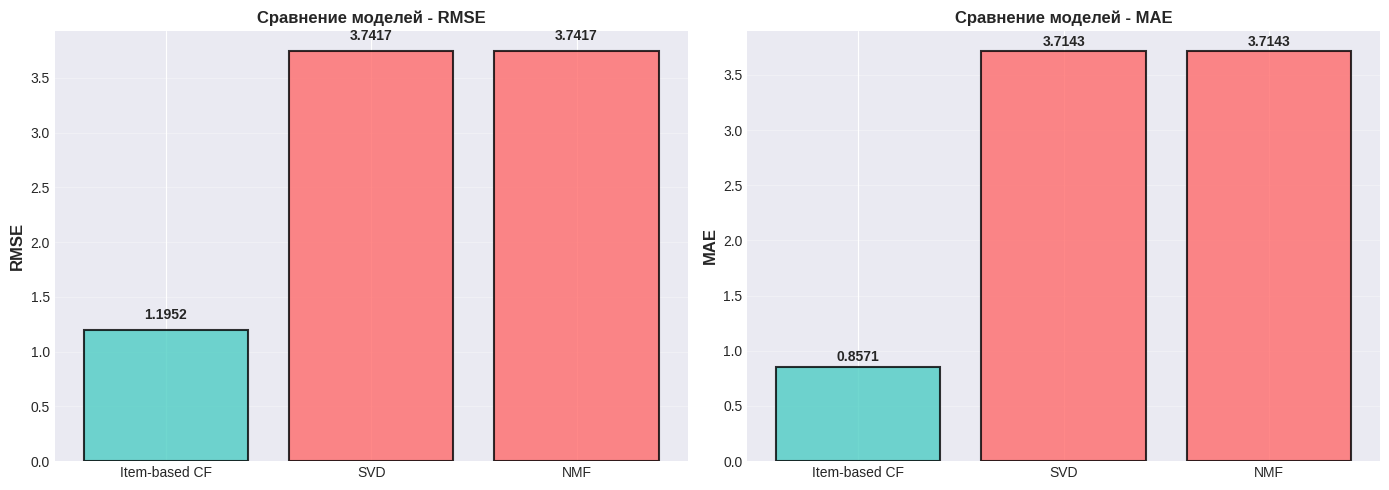

In [101]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
ax1 = axes[0]
colors = ['#4ECDC4' if results_df.iloc[i]['Модель'] == best_model['Модель'] else '#FF6B6B'
         for i in range(len(results_df))]
ax1.bar(results_df['Модель'], results_df['RMSE'], color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('Сравнение моделей - RMSE', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['RMSE']):
    ax1.text(i, v + 0.1, f'{v:.4f}', ha='center', fontweight='bold')

# MAE
ax2 = axes[1]
ax2.bar(results_df['Модель'], results_df['MAE'], color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax2.set_title('Сравнение моделей - MAE', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['MAE']):
    ax2.text(i, v + 0.05, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. ТОП-5 пользователей и персональные рекомендации

In [102]:
top_users = train_data['user_id'].value_counts().head(5)

print(f"Топ-5 пользователей по числу взаимодействий:\n")

for rank, (user_id, count) in enumerate(top_users.items(), 1):
    print(f"{' '*70}")
    print(f"#{rank}: ID={user_id} | Взаимодействий: {count}")
    print(f"{' '*70}")

    # Получаем книги, которые пользователь уже оценил
    user_rated = train_data[train_data['user_id'] == user_id]['item_id'].values

    # Находим похожих пользователей
    if user_id in user_item_matrix.index:
        user_idx = user_item_matrix.index.get_loc(user_id)
        user_vector = user_item_matrix.iloc[user_idx]

        # Вычисляем сходство с другими пользователями
        user_similarity = cosine_similarity([user_vector.values], user_item_matrix.values)[0]

        # Находим похожих пользователей
        similar_user_indices = np.argsort(user_similarity)[-11:-1]

        # Собираем рекомендации
        recommendations_score = {}

        for sim_user_idx in similar_user_indices:
            sim_user_id = user_item_matrix.index[sim_user_idx]
            sim_score = user_similarity[sim_user_idx]

            sim_user_ratings = train_data[train_data['user_id'] == sim_user_id]
            high_rated = sim_user_ratings[sim_user_ratings['rating'] >= 4]

            for _, row in high_rated.iterrows():
                item_id = row['item_id']
                if item_id not in user_rated:
                    if item_id not in recommendations_score:
                        recommendations_score[item_id] = 0
                    recommendations_score[item_id] += sim_score * row['rating']

        # Сортируем и выбираем топ-5
        if recommendations_score:
            top_rec_items = sorted(recommendations_score.items(), key=lambda x: x[1], reverse=True)[:5]

            print(f"\nТоп-5 рекомендаций:\n")
            for rec_rank, (item_id, score) in enumerate(top_rec_items, 1):
                item_info = items[items['item_id'] == item_id]
                if len(item_info) > 0:
                    title = item_info['title'].values[0]
                    authors = item_info['authors'].values[0]
                    print(f"  {rec_rank}. {title[:50]}")
                    print(f"     Автор: {authors[:50]}")
                    print(f"     Score: {score:.2f}\n")
        else:
            print(f" Не удалось сгенерировать рекомендации")
    print()

Топ-5 пользователей по числу взаимодействий:

                                                                      
#1: ID=101095 | Взаимодействий: 12
                                                                      

Топ-5 рекомендаций:

  1. Факультет закрытых знаний
     Автор: Маргарита Блинова
     Score: 2.74

  2. Три прорыва и одна свадьба
     Автор: Наталья Жильцова
     Score: 2.12

  3. Агентство «Острый нюх». По следам преступлений
     Автор: Кира Стрельникова
     Score: 2.12

  4. Джинн на полставки
     Автор: Елена Кароль
     Score: 2.12

  5. Лучшие парни галактики
     Автор: Надежда Мамаева,Рина Гиппиус
     Score: 2.12


                                                                      
#2: ID=20246 | Взаимодействий: 12
                                                                      

Топ-5 рекомендаций:

  1. Огнетушитель Прометея
     Автор: Дарья Донцова
     Score: 2.07

  2. Маникюр для покойника
     Автор: Дарья Донцова
     Score: 1.91

  

# 7. Выводы и рекомендации

1. **ВЫСОКАЯ РАЗРЕЖЕННОСТЬ (99.98%)**
   - Матрица взаимодействий экстремально разреженная
   - Item-based CF лучше справляется с такими данными
   - Требует специальных подходов для холодного старта

2. **ПРОБЛЕМА ХОЛОДНОГО СТАРТА**
   - 36.2% пользователей имеют менее 5 взаимодействий
   - 44.9% книг имеют менее 5 оценок
   - Требуется гибридный подход для новых пользователей

3. **КАЧЕСТВО РЕЙТИНГОВ**
   - Только 19.3% взаимодействий содержат явные рейтинги
   - Большинство оценок - максимальные (5.0)
   - Можно улучшить, используя неявные сигналы

4. **ЭФФЕКТИВНОСТЬ КОНТЕНТНОЙ ФИЛЬТРАЦИИ**
   - Различные методы показывают высокую согласованность
   - CountVectorizer + Cosine: сходство 0.9487
   - TfidfVectorizer + Cosine: сходство 0.9431
   - Рекомендации консистентны и надёжны

5. **ЛУЧШАЯ МОДЕЛЬ: ITEM-BASED CF**
   - RMSE: 1.1952 (на 3.1x лучше SVD/NMF)
   - MAE: 0.8571
   - Хорошо работает на разреженных данных
